# Simple Regression

### Import required packages

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

### Load the data

In [27]:
df=pd.read_csv('./Salary_Data.csv')

### EDA

In [28]:
df.head()

,YearsExperience,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [29]:
# get general info from the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  33 non-null     float64
 1   Salary           33 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 660.0 bytes


In [30]:
# perform correlation analysis
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.983642
Salary,0.983642,1.000000


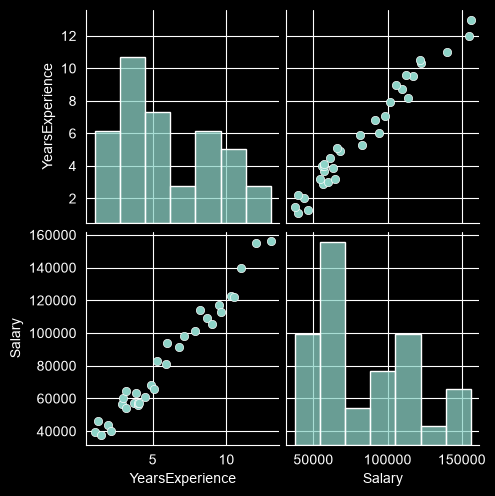

In [31]:
# visualize the dataset
sns.pairplot(df)

### data preparation

In [32]:
# split the data into x and y
x = df["YearsExperience"]
y = df["Salary"]

In [33]:
#convert the x and y into tensor format
# view (-1,1): change the one dimension to 2 dimensions dataset
x = torch.FloatTensor(x).view(-1,1)
y = torch.FloatTensor(y).view(-1,1)

In [34]:
y.ndim , x.ndim

(2, 2)

### Build The Model

In [35]:
# create a linear model
# y = weight * x + bias
model = torch.nn.Linear(in_features=1,out_features=1)

In [36]:
list(model.parameters())

[Parameter containing:
 tensor([[-0.0771]], requires_grad=True),
 Parameter containing:
 tensor([0.2180], requires_grad=True)]

### Initilalize The Hyperparameters

In [37]:
# number of epochs
epochs = 100

# learning rate
learning_rate = 0.001

# loss function
loss_function = torch.nn.MSELoss()

# optimizer
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

### Training Loop

In [38]:
# collect the errors
errors = []

for epoch in range(epochs):
    # forward propagation
    predictions = model(x)

    # calculate the loss using loss_function
    loss = loss_function(y,predictions)

    # zero out the old gradients
    optimizer.zero_grad()

    # calculate the loss gradients
    loss.backward()

    # optimize the model parameters
    optimizer.step()

    # append the loss
    # item() is used to convert the tensor to a simple float value
    errors.append(loss.item())

In [39]:
model

Linear(in_features=1, out_features=1, bias=True)

### model visualization

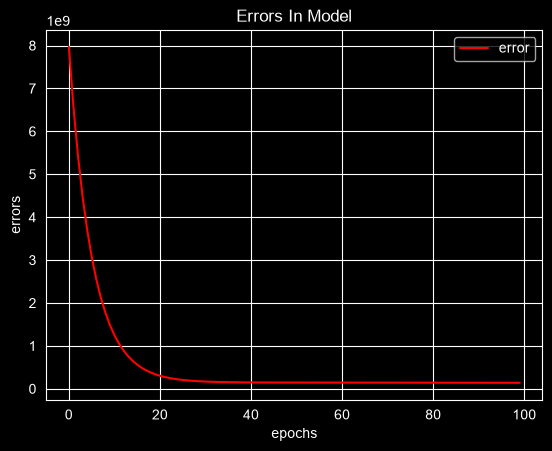

In [40]:
plt.plot(np.arange(epochs),errors,label="error",color="red")
plt.xlabel("epochs")
plt.ylabel("errors")
plt.title("Errors In Model")
plt.legend()

### model inference

In [41]:
# find salary of an employee having experience as 15
with torch.no_grad():
    salary = model(torch.tensor([[15.0]]))
    print(salary)

tensor([[193319.1094]])
